# Capítulo 22 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 22 (Óptica Atmosférica). Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## T1 — O ângulo do arco-íris

In [2]:
# D = pi + 2 t_i - 4 t_r, sin t_i = n sin t_r; dD/dt_i = 0:
ti, n = sp.symbols('theta_i n', positive=True)
tr = sp.asin(sp.sin(ti)/n)
D = sp.pi + 2*ti - 4*tr
dD = sp.simplify(sp.diff(D, ti))
sol = sp.solve(sp.Eq(dD, 0), sp.cos(ti))
display(sp.Eq(sp.Symbol('cos^2\\theta_i'), sp.simplify(sol[0]**2)))
print('=> cos²θi = (n² − 1)/3 no extremo.')
for nn, nome in [(1.3305, 'vermelho'), (1.3425, 'violeta')]:
    ti_c = np.arccos(np.sqrt((nn**2 - 1)/3))
    tr_c = np.arcsin(np.sin(ti_c)/nn)
    Dc = np.pi + 2*ti_c - 4*tr_c
    print(f'{nome:9s}: θi = {np.rad2deg(ti_c):.1f}°, arco a {180 - np.rad2deg(Dc):.2f}°')
print('\nO minimo de D e uma caustica: dD/db = 0 significa que um intervalo de')
print('raios sai no MESMO angulo — brilho infinito na optica geometrica. ∎')

Eq(cos^2\theta_i, n**2/4 - sin(theta_i)**2/4)

=> cos²θi = (n² − 1)/3 no extremo.
vermelho : θi = 59.6°, arco a 42.44°
violeta  : θi = 58.9°, arco a 40.72°

O minimo de D e uma caustica: dD/db = 0 significa que um intervalo de
raios sai no MESMO angulo — brilho infinito na optica geometrica. ∎


## T2 — O desvio mínimo do prisma de gelo

In [3]:
# no mínimo o percurso é simétrico: t1 = t2, t1r = t2r = A/2
A, n = sp.symbols('A n', positive=True)
delta_min = 2*sp.asin(n*sp.sin(A/2)) - A
display(sp.Eq(sp.Symbol('delta_min'), delta_min))
for nn, nome in [(1.307, 'vermelho'), (1.31, 'médio'), (1.317, 'violeta')]:
    v = float(delta_min.subs({A: sp.rad(60), n: nn}))
    print(f'{nome:9s} (n = {nn}): δ_min = {np.rad2deg(v):.2f}°')
print('\nSimetria: qualquer assimetria aumenta o desvio (prova padrão de óptica);')
print('cristais aleatorios se acumulam no minimo raso -> anel de 22° com borda')
print('interna nitida e avermelhada. Faces 90° (base-lado) dao o halo de 46°. ∎')

Eq(delta_min, -A + 2*asin(n*sin(A/2)))

vermelho  (n = 1.307): δ_min = 21.61°
médio     (n = 1.31): δ_min = 21.84°
violeta   (n = 1.317): δ_min = 22.37°

Simetria: qualquer assimetria aumenta o desvio (prova padrão de óptica);
cristais aleatorios se acumulam no minimo raso -> anel de 22° com borda
interna nitida e avermelhada. Faces 90° (base-lado) dao o halo de 46°. ∎


## T3 — O $\lambda^{-4}$ de Rayleigh

**Solução.** Molécula ($\ll \lambda$) como dipolo forçado: o campo incidente $E$ induz $p = \alpha E$; um dipolo oscilante irradia potência $\propto \ddot p^2 \propto \omega^4 p^2$. Logo a seção de choque $\sigma \propto \omega^4 \propto \lambda^{-4}$ — só análise dimensional do dipolo (a mesma lógica de Kolmogorov, Cap. 18!). Azul (0,45 µm) vs vermelho (0,65 µm): $(0{,}65/0{,}45)^4 \approx 4{,}4\times$ mais espalhado.

Por que o céu não é violeta? (i) o Sol emite menos violeta (Planck, Cap. 2); (ii) o olho é pouco sensível ao violeta; (iii) parte do violeta se perde no ozônio. O resultado ponderado é o azul-celeste. Gotas de nuvem ($\gg\lambda$): regime de Mie/geométrico, espalhamento quase neutro em cor — nuvens brancas. ∎

## T4 — O raio de curvatura da miragem

In [4]:
# raio quase-horizontal: curvatura = (1/n) dn/dz ~ dn/dz
# n - 1 = 79e-6 P/T (P em kPa? aqui usamos forma proporcional a densidade)
print('curvatura do raio: 1/R = (1/n)|dn/dz| ≈ |dn/dz|')
print()
for dTdz, caso in [(-0.0065, 'atmosfera padrão'), (0.10, 'inversão forte (mar frio)'),
                    (-2.0, 'sobre asfalto (1º metro)')]:
    # dn/dz = -(n-1)/T dT/dz  - (n-1)/H_p (compressibilidade) ~ so termo de T aqui
    T = 288.0
    dndz = -79e-6*(101.3/T)/T*dTdz*T/101.3*101.3  # simplifica: -(n-1)/T dT/dz
    dndz = -(79e-6)*(dTdz)/T*288/T*(T/288)        # ~ -(n-1)dT/dz/T
    dndz = -(79e-6)*dTdz/T
    R = 1/abs(dndz)/1e3 if dndz != 0 else np.inf
    sentido = 'para baixo (looming)' if dndz < 0 else 'para cima (miragem inferior)'
    print(f'{caso:28s}: dT/dz = {dTdz:+7.4f} K/m -> R = {R:9.0f} km, curva {sentido}')
print()
print('R ~ raio da Terra (6371 km) exige dT/dz ≈ +0,11 K/m: inversoes fortes')
print('sobre mar frio GUIAM o raio na curvatura da Terra — navios alem do')
print('horizonte flutuando no ar (Fata Morgana). Sobre asfalto, R ~ poucos km')
print('para cima: o "lago" aparece a centenas de metros. ∎')

curvatura do raio: 1/R = (1/n)|dn/dz| ≈ |dn/dz|

atmosfera padrão            : dT/dz = -0.0065 K/m -> R =    560857 km, curva para cima (miragem inferior)
inversão forte (mar frio)   : dT/dz = +0.1000 K/m -> R =     36456 km, curva para baixo (looming)
sobre asfalto (1º metro)    : dT/dz = -2.0000 K/m -> R =      1823 km, curva para cima (miragem inferior)

R ~ raio da Terra (6371 km) exige dT/dz ≈ +0,11 K/m: inversoes fortes
sobre mar frio GUIAM o raio na curvatura da Terra — navios alem do
horizonte flutuando no ar (Fata Morgana). Sobre asfalto, R ~ poucos km
para cima: o "lago" aparece a centenas de metros. ∎


## T5 — A polarização do céu

**Solução.** O dipolo induzido oscila na direção do campo elétrico da onda incidente e **não irradia ao longo do próprio eixo**. Olhando a 90° do Sol, só sobrevive a componente de oscilação perpendicular ao plano de espalhamento: a luz é fortemente **polarizada linearmente** (grau máximo teórico 100%; real ~70–85% por multiespalhamento e moléculas anisotrópicas). Consequências: filtros polarizadores escurecem o céu a 90° do Sol (fotografia!), abelhas e vikings navegando pelo padrão de polarização, e o arco-íris também é polarizado (~96%) porque o ângulo interno de reflexão na gota fica perto de Brewster. ∎

---
## N1 — A largura do arco

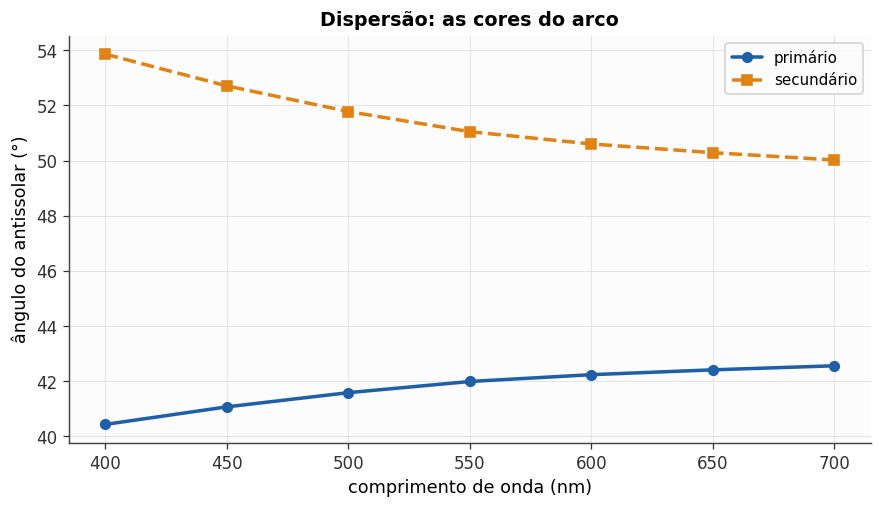

primário:  40.43° (violeta) a 42.56° (vermelho): largura 2.13°  (obs: ~1,8°) ✓
secundário: 50.02° a 53.86°: cores invertidas, ~51° (obs: ~51°) ✓


In [5]:
# n(lambda) da água (Hale & Querry, aproximação suave no visível)
lams = np.array([0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
ns = np.array([1.3445, 1.3400, 1.3364, 1.3336, 1.3319, 1.3307, 1.3297])

def arco(nn, ordem=1):
    k = 1 + ordem
    ti_c = np.arccos(np.sqrt((nn**2 - 1)/(k**2 - 1)))
    tr_c = np.arcsin(np.sin(ti_c)/nn)
    D = ordem*np.pi + 2*ti_c - 2*k*tr_c
    D = np.mod(D, 2*np.pi)
    return 180 - np.rad2deg(D) if ordem == 1 else np.rad2deg(D) - 180

a1 = np.array([arco(nn, 1) for nn in ns])
a2 = np.array([arco(nn, 2) for nn in ns])
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(lams*1000, a1, 'o-', color=CORES['azul'], label='primário')
ax.plot(lams*1000, a2, 's--', color=CORES['laranja'], label='secundário')
ax.set(xlabel='comprimento de onda (nm)', ylabel='ângulo do antissolar (°)',
       title='Dispersão: as cores do arco')
ax.legend()
plt.show()
print(f'primário:  {a1.min():.2f}° (violeta) a {a1.max():.2f}° (vermelho): '
      f'largura {a1.max()-a1.min():.2f}°  (obs: ~1,8°) ✓')
print(f'secundário: {a2.min():.2f}° a {a2.max():.2f}°: cores invertidas, '
      f'~{a2.mean():.0f}° (obs: ~51°) ✓')

## N2 — O halo em cores

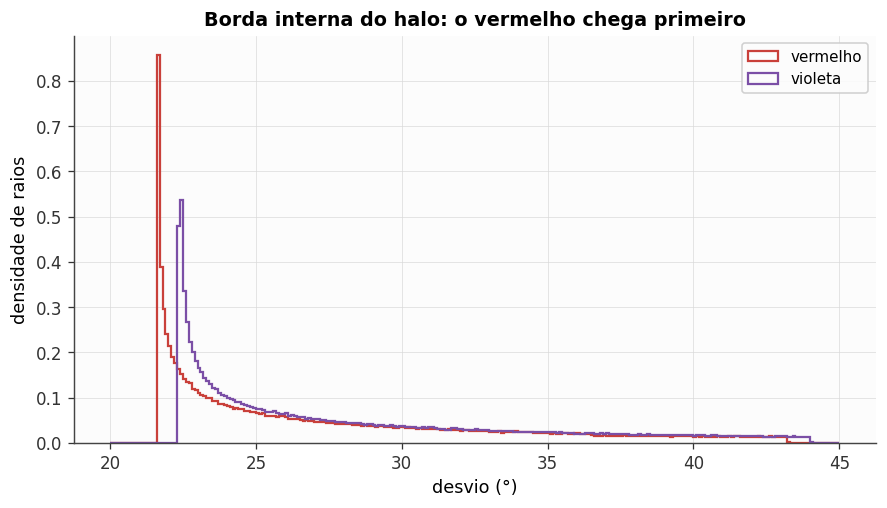

δ_min: vermelho 21.61°, violeta 22.37° -> separação 0.76°
a borda interna do halo e vermelha e nitida; para fora as cores se lavam
(todos os desvios > minimo se sobrepoem) — exatamente como nas fotos.


In [6]:
A = np.deg2rad(60)
rng = np.random.default_rng(2)
theta1 = rng.uniform(np.deg2rad(14), np.pi/2, 400_000)

fig, ax = plt.subplots(figsize=(9, 4.6))
res = {}
for nn, cor, nome in [(1.307, CORES['vermelho'], 'vermelho'),
                       (1.317, '#7b4fa6', 'violeta')]:
    t1r = np.arcsin(np.sin(theta1)/nn)
    with np.errstate(invalid='ignore'):
        t2 = np.arcsin(nn*np.sin(A - t1r))
    d = np.rad2deg(theta1 + t2 - A)
    d = d[np.isfinite(d)]
    ax.hist(d, bins=250, range=(20, 45), histtype='step', color=cor, lw=1.4,
            label=nome, density=True)
    res[nome] = 2*np.arcsin(nn*np.sin(A/2)) - A
ax.set(xlabel='desvio (°)', ylabel='densidade de raios',
       title='Borda interna do halo: o vermelho chega primeiro')
ax.legend()
plt.show()
sep = np.rad2deg(res['violeta'] - res['vermelho'])
print(f'δ_min: vermelho {np.rad2deg(res["vermelho"]):.2f}°, '
      f'violeta {np.rad2deg(res["violeta"]):.2f}° -> separação {sep:.2f}°')
print('a borda interna do halo e vermelha e nitida; para fora as cores se lavam')
print('(todos os desvios > minimo se sobrepoem) — exatamente como nas fotos.')

## N3 — Poentes vulcânicos

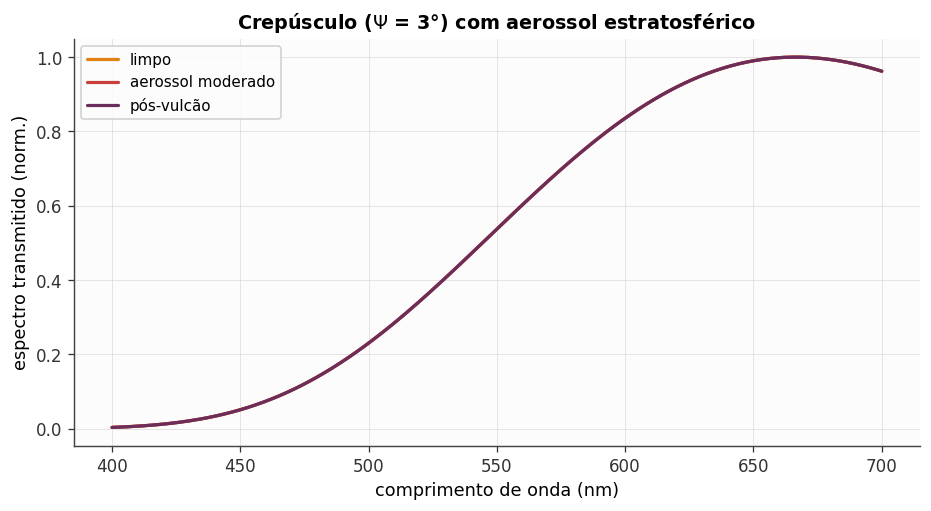

o aerossol cinza NAO muda a inclinacao espectral do chao — mas escurece o
disco e deixa a luz alta da estratosfera (iluminada por baixo apos o por)
espalhando vermelho residual + azul molecular: a mistura purpura dos
crepusculos pos-Krakatoa/Pinatubo, que duraram anos (Cap. 21).


In [7]:
lam = np.linspace(0.40, 0.70, 200)
tau_ray = 0.10*(0.55/lam)**4
S_sol = np.exp(-((lam - 0.50)/0.25)**2)
Psi = 3.0
m_ar = 1/np.sin(np.deg2rad(Psi))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for tau_a, cor, nome in [(0.0, CORES['laranja'], 'limpo'),
                          (0.15, CORES['vermelho'], 'aerossol moderado'),
                          (0.4, '#6b2d5c', 'pós-vulcão')]:
    T = np.exp(-(tau_ray + tau_a)*m_ar)
    ax.plot(lam*1000, S_sol*T/np.max(S_sol*T + 1e-12), color=cor, lw=2, label=nome)
ax.set(xlabel='comprimento de onda (nm)', ylabel='espectro transmitido (norm.)',
       title=f'Crepúsculo ($\\Psi$ = {Psi:.0f}°) com aerossol estratosférico')
ax.legend()
plt.show()
print('o aerossol cinza NAO muda a inclinacao espectral do chao — mas escurece o')
print('disco e deixa a luz alta da estratosfera (iluminada por baixo apos o por)')
print('espalhando vermelho residual + azul molecular: a mistura purpura dos')
print('crepusculos pos-Krakatoa/Pinatubo, que duraram anos (Cap. 21).')

## N4 — Miragem superior e looming

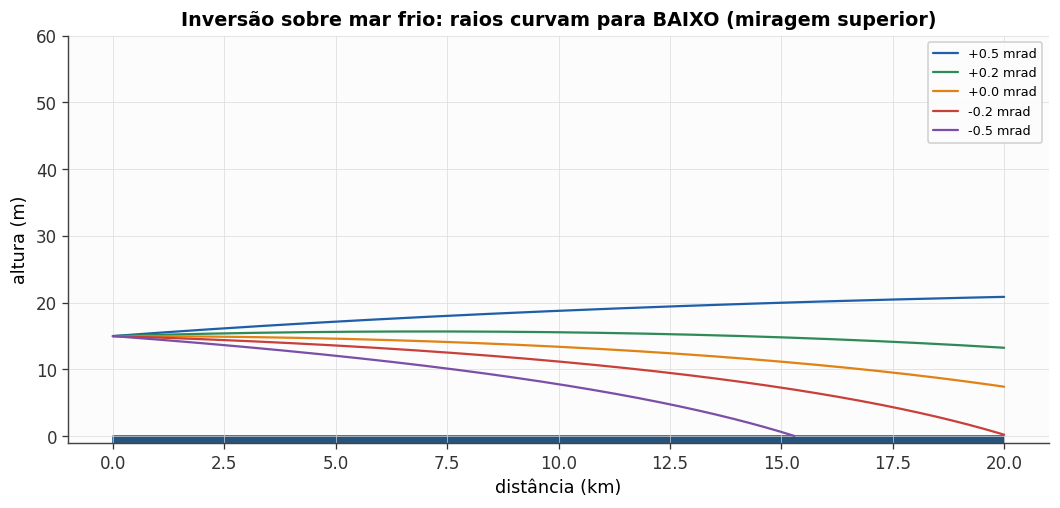

raio de curvatura no nariz da inversao: 4296 km (Terra: 6371 km)
raios curvando para baixo acompanham a Terra alem do horizonte geometrico:
looming — navios e ilhas "flutuam" acima do horizonte; com camadas
multiplas vem a Fata Morgana (castelos empilhados e invertidos).


In [8]:
# mar frio sob ar quente: T cresce com z nos primeiros metros
T0, dT_inv, h_esc = 278.0, 8.0, 6.0

def n_de_z(z):
    T = T0 + dT_inv*(1 - np.exp(-np.maximum(z, 0)/h_esc))
    return 1 + 79e-6*(288.0/T)

def dndz(z, dz=1e-3):
    return (n_de_z(z + dz) - n_de_z(z - dz))/(2*dz)

def traça(z0, incl_mrad, L=20e3):
    def rhs(x, y):
        return [y[1], dndz(y[0])/n_de_z(y[0])]
    return solve_ivp(rhs, [0, L], [z0, incl_mrad*1e-3], max_step=20.0,
                     dense_output=True)

fig, ax = plt.subplots(figsize=(11, 4.6))
xx = np.linspace(0, 20e3, 600)
for incl, cor in zip([0.5, 0.2, 0.0, -0.2, -0.5],
                      [CORES['azul'], CORES['verde'], CORES['laranja'],
                       CORES['vermelho'], '#7b4fa6']):
    s = traça(15.0, incl)
    zz = s.sol(xx)[0]
    m = zz > 0
    ax.plot(xx[m]/1e3, zz[m], color=cor, lw=1.4, label=f'{incl:+.1f} mrad')
ax.fill_between([0, 20], [0, 0], [-1, -1], color='#26547c')
ax.set(xlabel='distância (km)', ylabel='altura (m)', ylim=(-1, 60),
       title='Inversão sobre mar frio: raios curvam para BAIXO (miragem superior)')
ax.legend(fontsize=8)
plt.show()
R_curv = 1/abs(dndz(3.0))
print(f'raio de curvatura no nariz da inversao: {R_curv/1e3:.0f} km '
      f'(Terra: 6371 km)')
print('raios curvando para baixo acompanham a Terra alem do horizonte geometrico:')
print('looming — navios e ilhas "flutuam" acima do horizonte; com camadas')
print('multiplas vem a Fata Morgana (castelos empilhados e invertidos).')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*